In [32]:
import os
import glob
from enum import Enum

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches


In [33]:
class Channel(Enum):
    Player_1_Worker = 0
    Player_1_Ground = 1
    Player_1_Air = 2
    Player_1_Building = 3
    
    Player_2_Worker = 4
    Player_2_Ground = 5
    Player_2_Air = 6
    Player_2_Building = 7
    
    Resource = 8
    Vision = 9
    Terrain = 10

In [85]:
prediction_dir = os.path.join(os.path.split(os.getcwd())[0], "predictions")
predictions = glob.glob(os.path.join(prediction_dir, "*.json"))

In [82]:
# open json files and load them
predictions_data = []
for prediction in predictions:
    with open(prediction, 'r') as f:
        data = json.load(f)
        predictions_data.append(data)

In [46]:
annotations = pd.DataFrame(predictions_data[0]['annotations'])

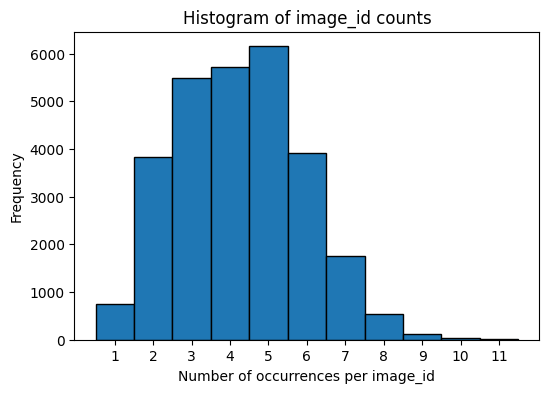

In [83]:
counts = annotations.groupby('image_id').size()
plt.figure(figsize=(6, 4))
plt.hist(counts, bins=range(1, counts.max() + 2), edgecolor='black', align='left')
plt.xlabel('Number of occurrences per image_id')
plt.ylabel('Frequency')
plt.title('Histogram of image_id counts')
plt.xticks(range(1, counts.max() + 1))
plt.show()

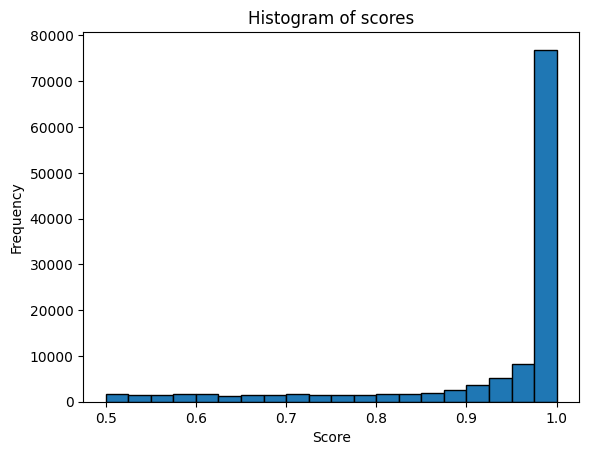

In [84]:
plt.hist(annotations['score'], bins=20, edgecolor='black')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.title('Histogram of scores')
plt.show()

In [86]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def draw_overview(data, rep_name, frame, segmentations=None, ground_truths=None):
    plt.figure(figsize=(6, 6), dpi=300)

    # Terrain & resource
    plt.imshow(data[Channel.Terrain.value] > 0, cmap='Greys', alpha=0.5)
    resource_alpha = np.where(data[Channel.Resource.value] == 1, 1.0, 0.0)
    plt.imshow(data[Channel.Resource.value] == 1, cmap='GnBu', alpha=resource_alpha)

    # Player colors
    p1_cmap='Greens'
    p2_cmap='Reds'

    # Player 1 & 2 - worker
    player_1_worker_alpha = np.where(data[Channel.Player_1_Worker.value] != 0, 1.0, 0.0)
    player_2_worker_alpha = np.where(data[Channel.Player_2_Worker.value] != 0, 1.0, 0.0)
    plt.imshow(data[Channel.Player_1_Worker.value] != 0, cmap=p1_cmap, alpha=player_1_worker_alpha)
    plt.imshow(data[Channel.Player_2_Worker.value] != 0, cmap=p2_cmap, alpha=player_2_worker_alpha)

    # Player 1 & 2 - ground
    player_1_ground_alpha = np.where(data[Channel.Player_1_Ground.value] != 0, 1.0, 0.0)
    player_2_ground_alpha = np.where(data[Channel.Player_2_Ground.value] != 0, 1.0, 0.0)
    plt.imshow(data[Channel.Player_1_Ground.value] != 0, cmap=p1_cmap, alpha=player_1_ground_alpha)
    plt.imshow(data[Channel.Player_2_Ground.value] != 0, cmap=p2_cmap, alpha=player_2_ground_alpha)

    # Player 1 & 2 - air
    player_1_air_alpha = np.where(data[Channel.Player_1_Air.value] != 0, 1.0, 0.0)
    player_2_air_alpha = np.where(data[Channel.Player_2_Air.value] != 0, 1.0, 0.0)
    plt.imshow(data[Channel.Player_1_Air.value] != 0, cmap=p1_cmap, alpha=player_1_air_alpha)
    plt.imshow(data[Channel.Player_2_Air.value] != 0, cmap=p2_cmap, alpha=player_2_air_alpha)

    # Player 1 & 2 - building
    player_1_building_alpha = np.where(data[Channel.Player_1_Building.value] != 0, 1.0, 0.0)
    player_2_building_alpha = np.where(data[Channel.Player_2_Building.value] != 0, 1.0, 0.0)
    plt.imshow(data[Channel.Player_1_Building.value] != 0, cmap=p1_cmap, alpha=player_1_building_alpha)
    plt.imshow(data[Channel.Player_2_Building.value] != 0, cmap=p2_cmap, alpha=player_2_building_alpha)
    
    # Vision mask
    vision_alpha = np.where(data[Channel.Vision.value] == 1, 0.0, 0.9)
    plt.imshow(np.zeros_like(data[Channel.Vision.value]), cmap='Greys_r', alpha=vision_alpha)

    # --- Segmentation Overlay ---
    if segmentations is not None:
        ax = plt.gca()
        colors = plt.cm.tab10(np.linspace(0, 1, len(segmentations)))
        for color, seg in zip(colors, segmentations):
            coords = np.array(seg[0]).reshape(-1, 2)
            polygon = patches.Polygon(coords, linewidth=1.5, edgecolor=color, facecolor='none')
            ax.add_patch(polygon)

    # --- Ground Truth Overlay ---
    if ground_truths is not None:
        ax = plt.gca()
        gt_color = 'red'
        for gt in ground_truths:
            coords = np.array(gt[0]).reshape(-1, 2)
            polygon = patches.Polygon(coords, linewidth=1.5, edgecolor=gt_color, facecolor='none', linestyle='--')
            ax.add_patch(polygon)

    plt.axis('off')
    plt.tight_layout()

    os.makedirs(f'figures/{rep_name}', exist_ok=True)
    plt.savefig(f'figures/{rep_name}/{rep_name}_{frame}_Overview.png', bbox_inches='tight', pad_inches=0)
    # plt.show()


In [ ]:
unique_ids = annotations['image_id'].unique()
random_ids = np.random.choice(unique_ids, replace=False)
print(f"Randomly selected image_ids: {random_ids}")

prediction_results = annotations.loc[annotations['image_id'] == random_ids]
print(f"Number of segmentations: {len(prediction_results)}")

Randomly selected image_ids: 25989
Number of segmentations: 4


In [91]:
images = predictions_data[0]['images']
image_path = next((item for item in images if item['id'] == random_ids), None)

In [92]:
input_root = os.path.join(os.path.split(os.getcwd())[0], "data", "input", "dst")
input_path = os.path.join(input_root, image_path['file_name'])
input_numpy = np.load(input_path)
rep_name, frame_npy = image_path['file_name'].split('/')

In [104]:
ground_truth_root = os.path.join(os.path.split(os.getcwd())[0], "data", "label", "dst")
ground_truth_path = os.path.join(ground_truth_root, rep_name, 'all_correct.json')
ground_truth_all_correct = json.load(open(ground_truth_path, 'r'))

In [105]:
ground_truth_all_correct

{'info': {'description': 'Viewport annotations for replay 36',
  'version': '1.0',
  'year': 2025,
  'date_created': '2025-05-30 05:23:47'},
 'licenses': [],
 'images': [{'id': 0,
   'file_name': 'input/dst/36/0.npy',
   'width': 128,
   'height': 128},
  {'id': 1, 'file_name': 'input/dst/36/1.npy', 'width': 128, 'height': 128},
  {'id': 2, 'file_name': 'input/dst/36/2.npy', 'width': 128, 'height': 128},
  {'id': 3, 'file_name': 'input/dst/36/3.npy', 'width': 128, 'height': 128},
  {'id': 4, 'file_name': 'input/dst/36/4.npy', 'width': 128, 'height': 128},
  {'id': 5, 'file_name': 'input/dst/36/5.npy', 'width': 128, 'height': 128},
  {'id': 6, 'file_name': 'input/dst/36/6.npy', 'width': 128, 'height': 128},
  {'id': 7, 'file_name': 'input/dst/36/7.npy', 'width': 128, 'height': 128},
  {'id': 8, 'file_name': 'input/dst/36/8.npy', 'width': 128, 'height': 128},
  {'id': 9, 'file_name': 'input/dst/36/9.npy', 'width': 128, 'height': 128},
  {'id': 10, 'file_name': 'input/dst/36/10.npy', 'wid

In [96]:
rep_name, frame_npy

('36.rep', '25989.npy')

In [94]:
ground_truth_path

'/home/bcm/workspace/starcraft/data/label/dst/36.rep/25989.npy'

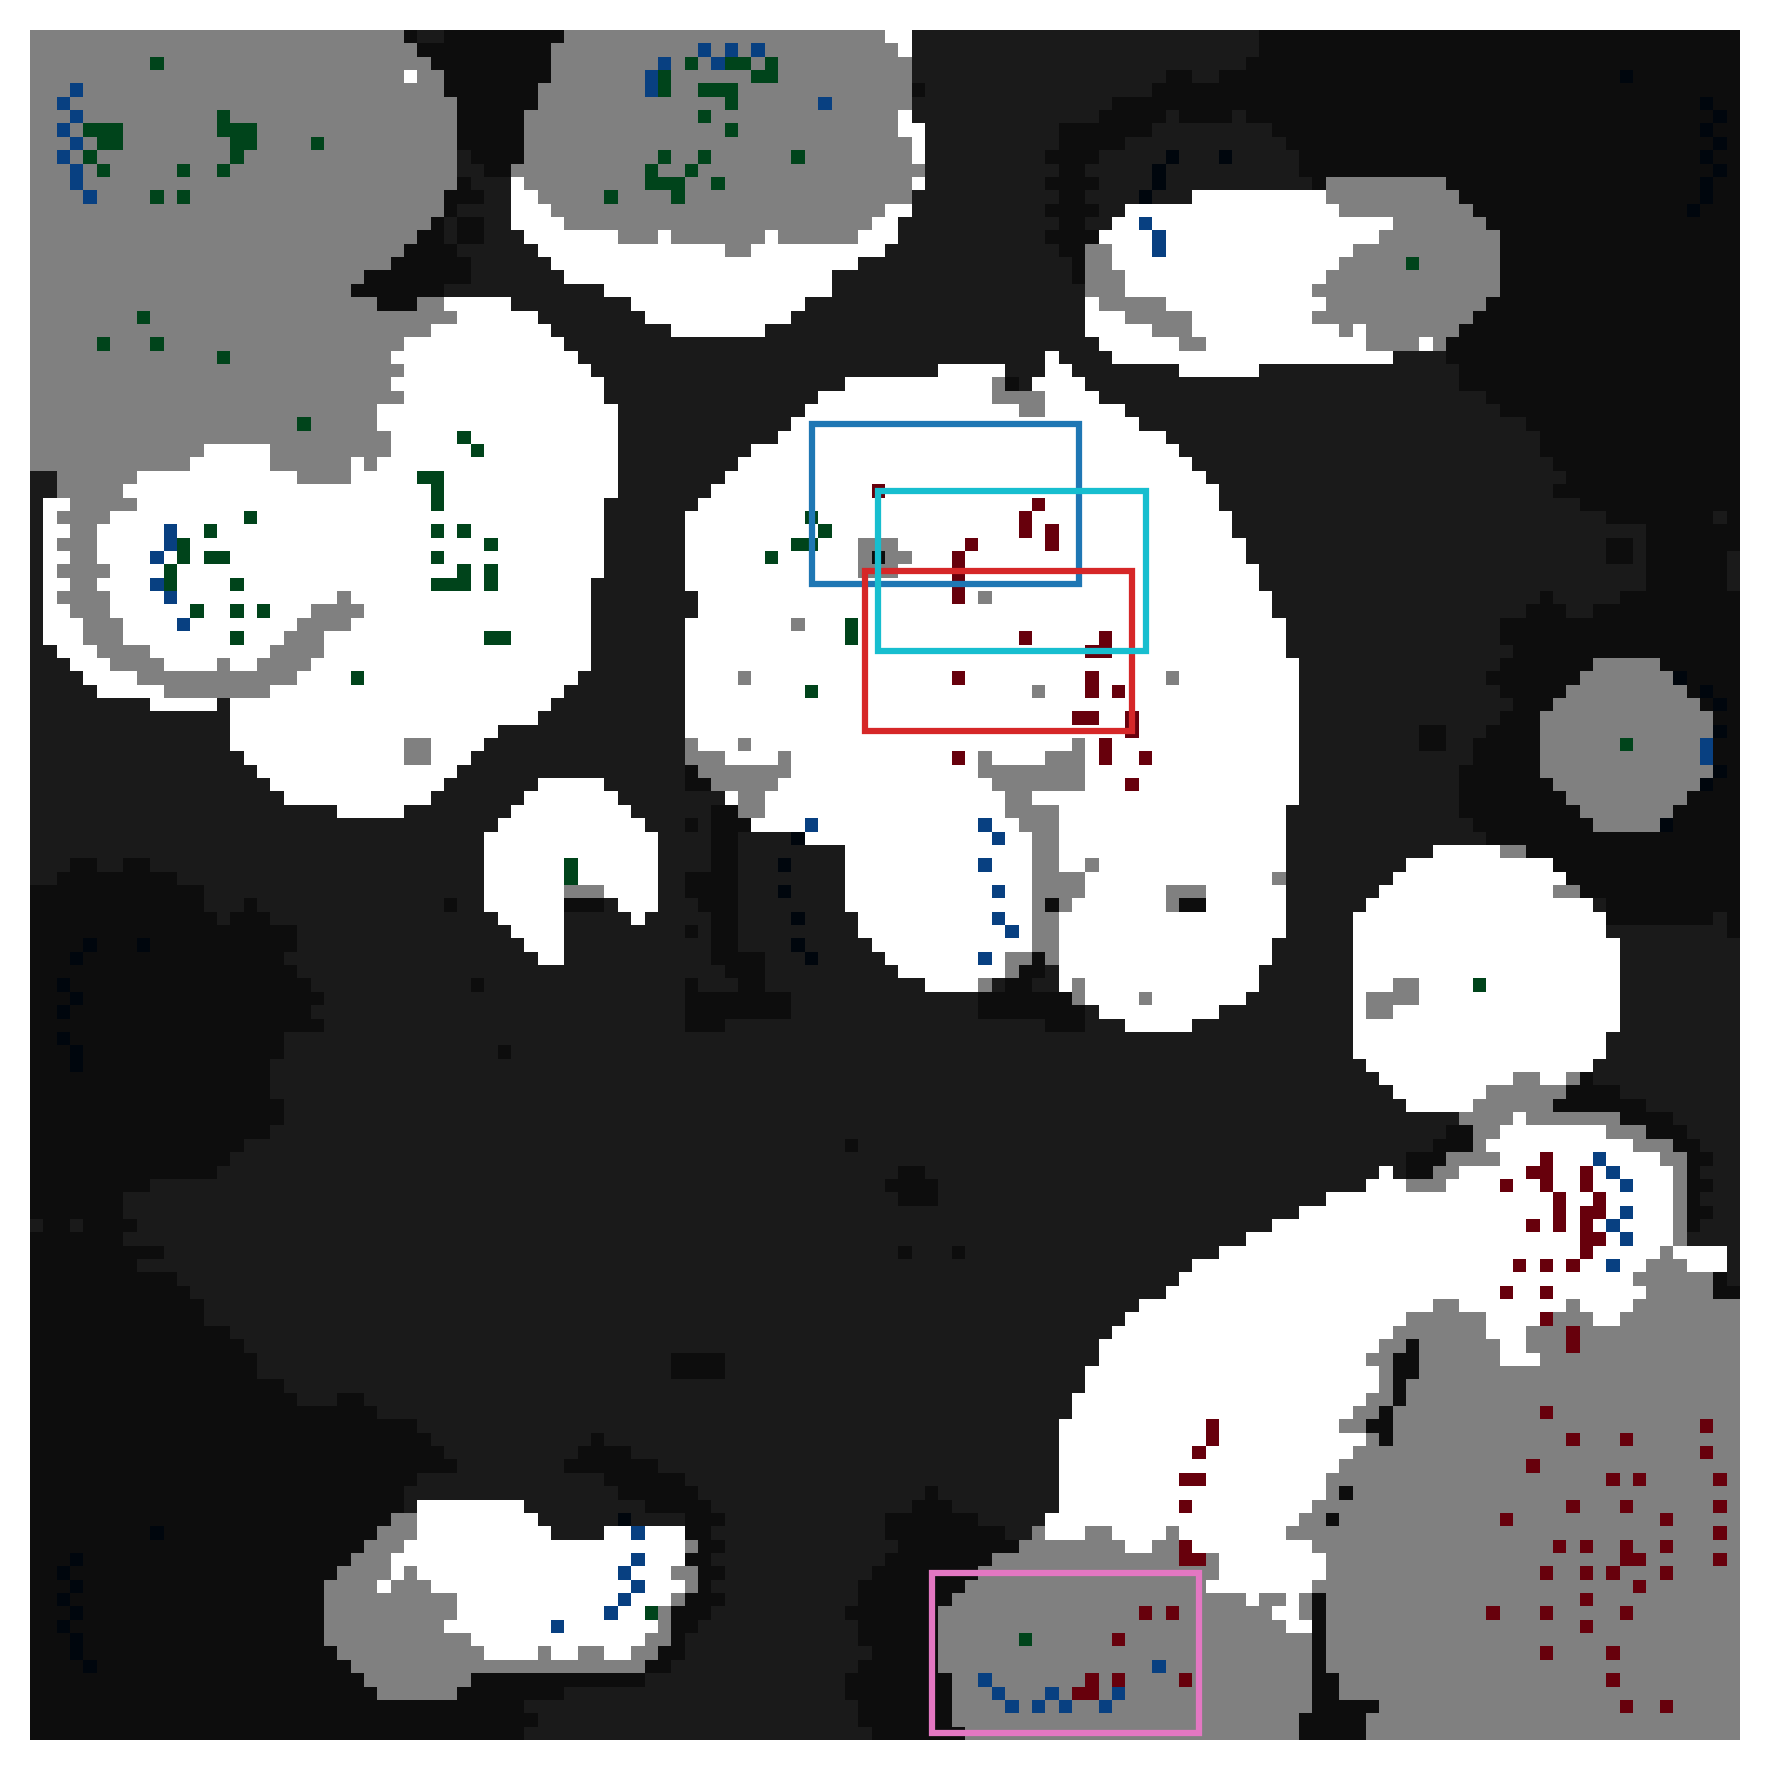

In [ ]:
draw_overview(input_numpy, rep_name, frame_npy.split('.')[0], segmentations=samples['segmentation'].tolist())